# 02 — Theme 1 crosstabs (Awareness / Engagement)

Narrative: **What exists → What each brand uses → How strategies combine → What performs best.**

Presentation notes:
- Shares and median WER shown as **percentages**; views use thousands separators
- Category codes → readable labels (`product_showcase` → Product Showcase); missing → **Unclassified**
- Gray / hatch / `*` marks **small-n** categories (n < 15)
- One primary chart + at most one compact table per question
- Cluster id: `content_cluster_id_clean_k12` (names from `content_cluster_profiles_clean_k12.json`)

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from tiktok_brand.analysis.data import CLUSTER_COL, load_feature_table, project_paths
from tiktok_brand.analysis.crosstabs import (
    brand_vs_label,
    one_way_with_wer,
    crosstab_performance,
    mannwhitney_wer_by_brand,
)
from tiktok_brand.analysis.plots import (
    landscape_hbar,
    brand_compare_hbar,
    crosstab_heatmap,
    performance_bubble,
    brand_wer_violin,
    relative_uplift_diverging,
    scalable_winners_scatter,
)
from tiktok_brand.analysis.present import (
    one_way_display_table,
    brand_pivot_display,
    coverage_annotation,
)
from tiktok_brand.analysis.within_brand import (
    brand_baseline_wer,
    relative_performance_by_category,
    relative_display_table,
    category_vs_rest_tests,
    tests_display_table,
    auto_findings,
)

PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
df["content_cluster"] = df[CLUSTER_COL]

LANDSCAPE_DIMS = [
    ("content_type", "Content type"),
    ("visual_format", "Visual format"),
    ("social_mechanic", "Social mechanic"),
    ("brand_styles", "Brand styles"),
    ("content_cluster", "Content cluster"),
]
print(f"rows={len(df):,}  cols={df.shape[1]}")

rows=4,457  cols=121


## Part 1 — Content landscape

What content exists in the sample? Share of each category within the labeled set.

Coverage: 976 / 4,457 videos (21.9%)
Coverage: 4,457 / 4,457 videos (100.0%)
Coverage: 585 / 4,457 videos (13.1%)
Coverage: 1,118 / 4,457 videos (25.1%)
Coverage: 4,457 / 4,457 videos (100.0%)


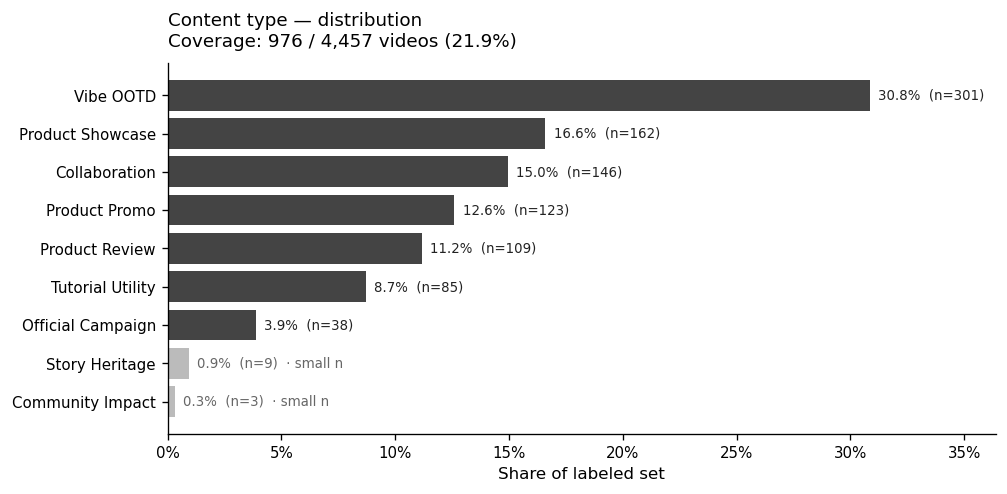

,Category,Share,Median WER,n
0,Vibe OOTD,30.8%,0.76%,301
1,Product Showcase,16.6%,0.57%,162
2,Collaboration,15.0%,0.74%,146
3,Product Promo,12.6%,0.53%,123
4,Product Review,11.2%,0.55%,109
5,Tutorial Utility,8.7%,0.59%,85
6,Official Campaign,3.9%,0.32%,38
7,Story Heritage,0.9%,0.86%,9
8,Community Impact,0.3%,0.68%,3


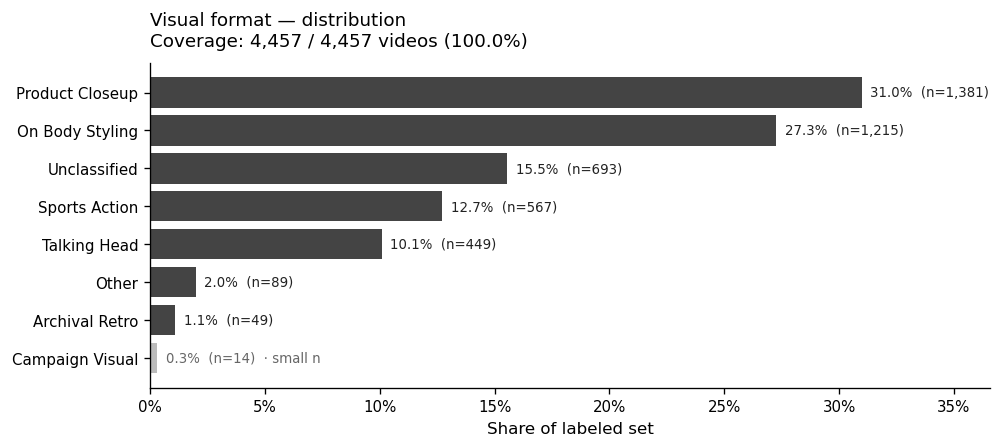

,Category,Share,Median WER,n
0,Product Closeup,31.0%,0.66%,"1,381"
1,On Body Styling,27.3%,0.61%,"1,215"
2,Unclassified,15.5%,0.68%,693
3,Sports Action,12.7%,0.63%,567
4,Talking Head,10.1%,0.57%,449
5,Other,2.0%,0.72%,89
6,Archival Retro,1.1%,0.71%,49
7,Campaign Visual,0.3%,0.57%,14


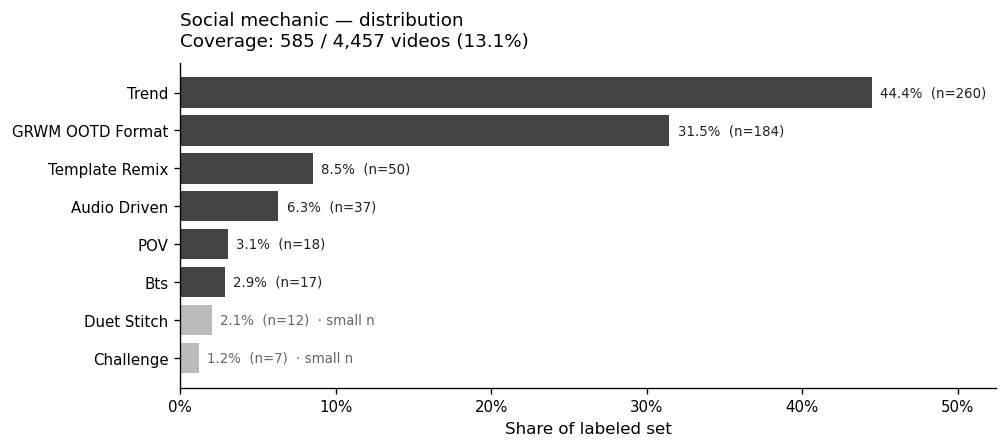

,Category,Share,Median WER,n
0,Trend,44.4%,0.77%,260
1,GRWM OOTD Format,31.5%,0.76%,184
2,Template Remix,8.5%,0.74%,50
3,Audio Driven,6.3%,0.52%,37
4,POV,3.1%,0.92%,18
5,Bts,2.9%,0.56%,17
6,Duet Stitch,2.1%,0.44%,12
7,Challenge,1.2%,0.61%,7


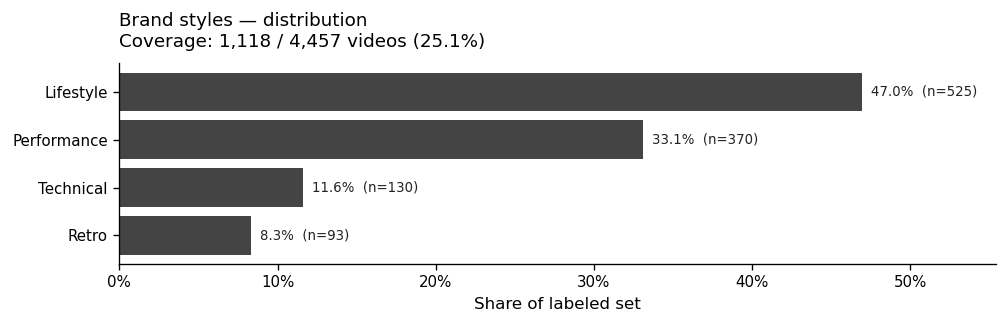

,Category,Share,Median WER,n
0,Lifestyle,47.0%,0.71%,525
1,Performance,33.1%,0.57%,370
2,Technical,11.6%,0.71%,130
3,Retro,8.3%,0.57%,93


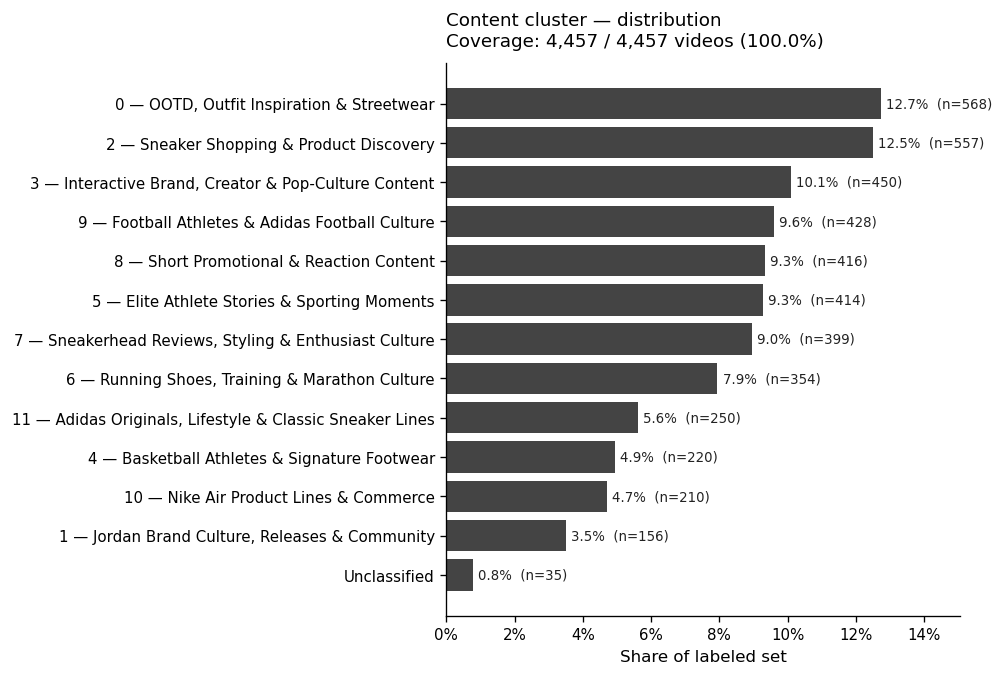

,Category,Share,Median WER,n
0,"0 — OOTD, Outfit Inspiration & Streetwear",12.7%,0.71%,568
1,2 — Sneaker Shopping & Product Discovery,12.5%,0.58%,557
2,"3 — Interactive Brand, Creator & Pop-Culture Content",10.1%,0.65%,450
3,9 — Football Athletes & Adidas Football Culture,9.6%,0.85%,428
4,8 — Short Promotional & Reaction Content,9.3%,0.65%,416
5,5 — Elite Athlete Stories & Sporting Moments,9.3%,0.50%,414
6,"7 — Sneakerhead Reviews, Styling & Enthusiast Culture",9.0%,0.59%,399
7,"6 — Running Shoes, Training & Marathon Culture",7.9%,0.67%,354
8,"11 — Adidas Originals, Lifestyle & Classic Sneaker Lines",5.6%,0.61%,250
9,4 — Basketball Athletes & Signature Footwear,4.9%,0.67%,220


In [2]:
for col, title in LANDSCAPE_DIMS:
    raw = one_way_with_wer(df, col, min_count=3)
    print(coverage_annotation(raw))
    display(landscape_hbar(raw, title=f"{title} — distribution"))
    display(one_way_display_table(raw))


## Part 2 — Nike vs Adidas strategy

Within-brand mix for each dimension (grouped bars) plus a compact brand-column pivot.

Coverage: 976 / 4,457 videos (21.9%)
Coverage: 4,457 / 4,457 videos (100.0%)
Coverage: 585 / 4,457 videos (13.1%)
Coverage: 1,118 / 4,457 videos (25.1%)
Coverage: 4,457 / 4,457 videos (100.0%)


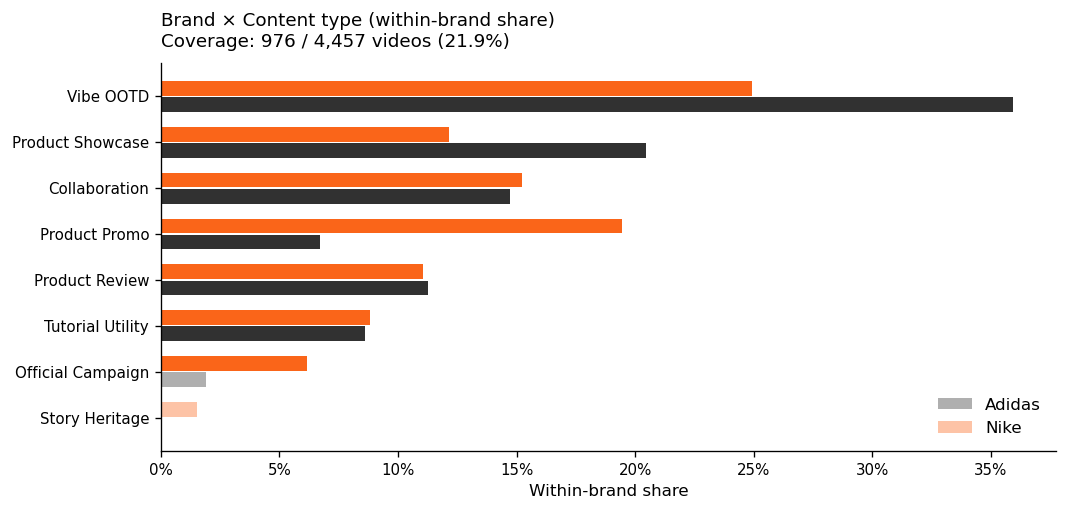

,Adidas share,Adidas WER,Adidas n,Nike share,Nike WER,Nike n
Content type,,,,,,
Vibe OOTD,35.9%,0.85%,188,24.9%,0.61%,113
Product Showcase,20.5%,0.73%,107,12.1%,0.43%,55
Collaboration,14.7%,0.79%,77,15.2%,0.67%,69
Product Promo,6.7%,0.53%,35,19.4%,0.54%,88
Product Review,11.3%,0.44%,59,11.0%,0.60%,50
Tutorial Utility,8.6%,0.54%,45,8.8%,0.66%,40
Official Campaign,1.9%,0.81%,10,6.2%,0.19%,28
Story Heritage,—,—,—,1.5%,0.86%,7


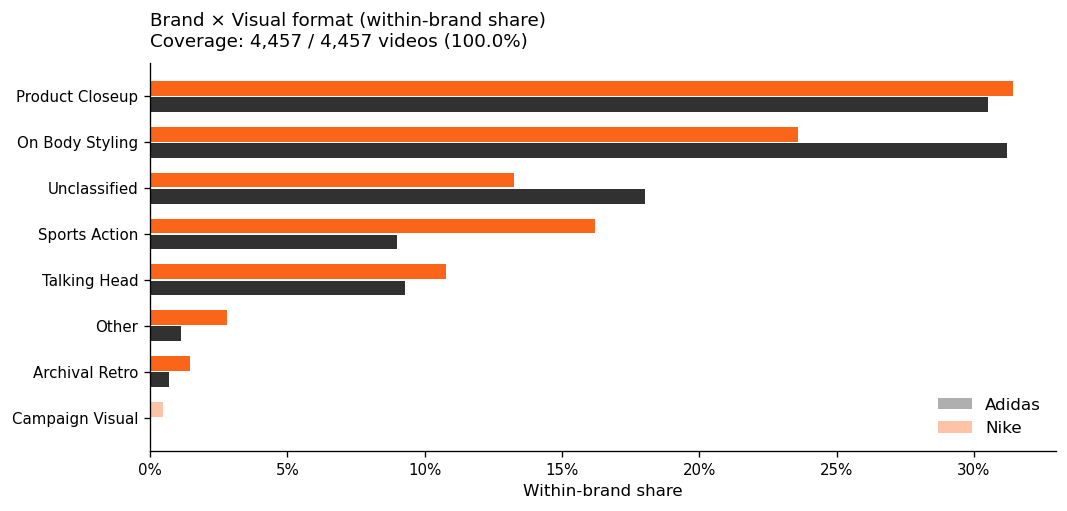

,Adidas share,Adidas WER,Adidas n,Nike share,Nike WER,Nike n
Visual format,,,,,,
Product Closeup,30.5%,0.68%,653,31.4%,0.65%,728
On Body Styling,31.2%,0.68%,668,23.6%,0.56%,547
Unclassified,18.0%,0.70%,386,13.2%,0.65%,307
Sports Action,9.0%,0.76%,192,16.2%,0.56%,375
Talking Head,9.3%,0.76%,199,10.8%,0.48%,250
Other,1.1%,1.15%,24,2.8%,0.60%,65
Archival Retro,0.7%,1.15%,15,1.5%,0.62%,34
Campaign Visual,—,—,—,0.5%,0.46%,11


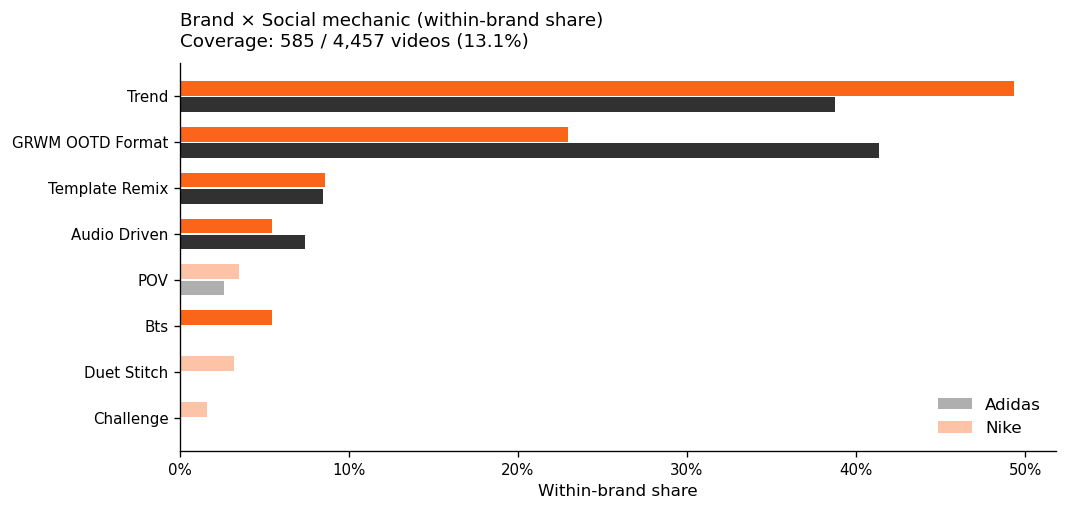

,Adidas share,Adidas WER,Adidas n,Nike share,Nike WER,Nike n
Social mechanic,,,,,,
Trend,38.7%,0.89%,105,49.4%,0.74%,155
GRWM OOTD Format,41.3%,0.87%,112,22.9%,0.57%,72
Template Remix,8.5%,0.62%,23,8.6%,0.97%,27
Audio Driven,7.4%,0.60%,20,5.4%,0.48%,17
POV,2.6%,0.70%,7,3.5%,0.95%,11
Bts,—,—,—,5.4%,0.56%,17
Duet Stitch,—,—,—,3.2%,0.44%,10
Challenge,—,—,—,1.6%,0.74%,5


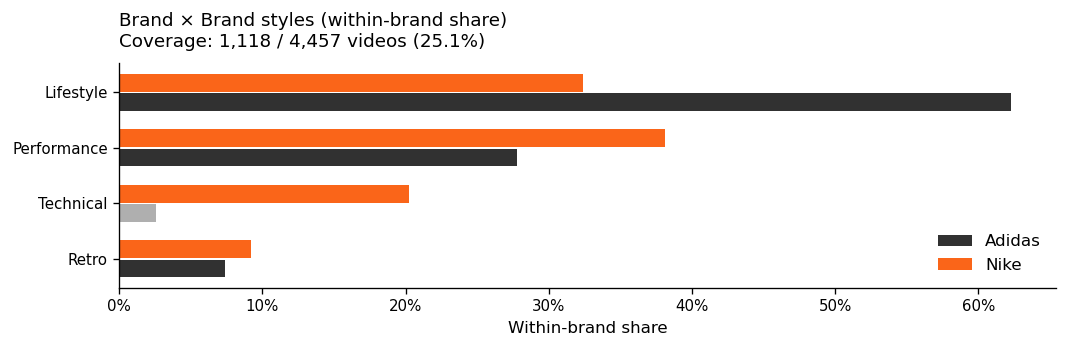

,Adidas share,Adidas WER,Adidas n,Nike share,Nike WER,Nike n
Brand style,,,,,,
Lifestyle,62.3%,0.74%,339,32.4%,0.64%,186
Performance,27.8%,0.57%,151,38.2%,0.57%,219
Technical,2.6%,0.55%,14,20.2%,0.73%,116
Retro,7.4%,0.43%,40,9.2%,0.69%,53


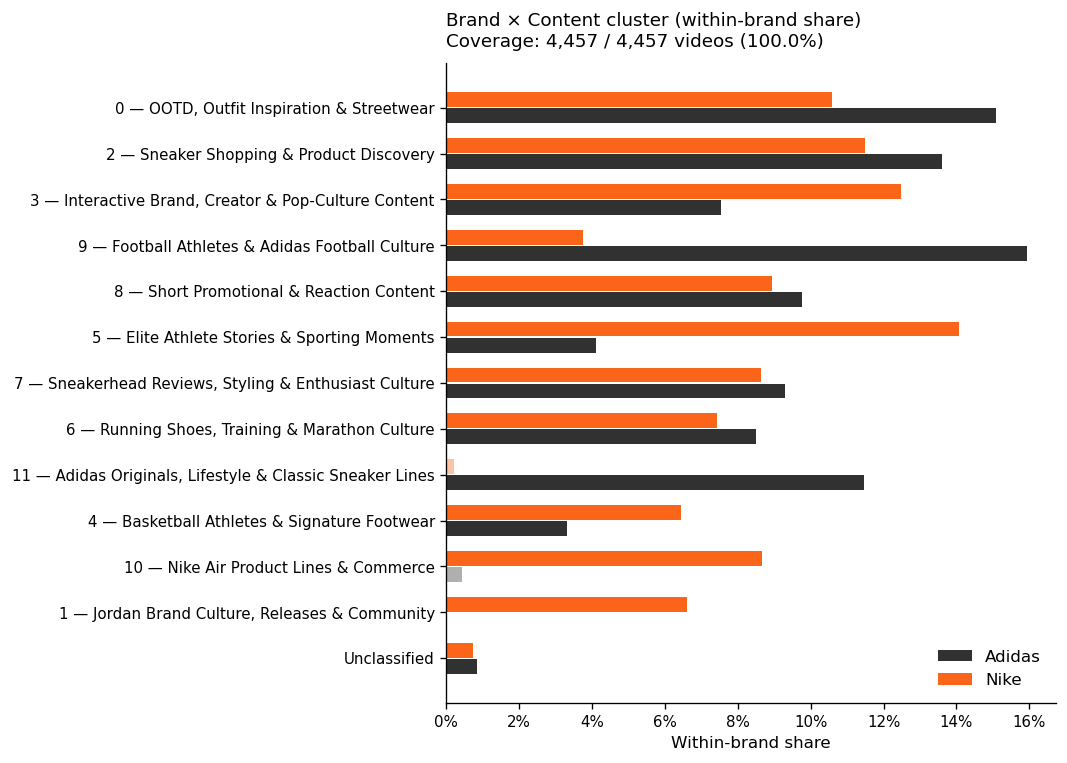

,Adidas share,Adidas WER,Adidas n,Nike share,Nike WER,Nike n
Cluster,,,,,,
"0 — OOTD, Outfit Inspiration & Streetwear",15.1%,0.85%,323,10.6%,0.57%,245
2 — Sneaker Shopping & Product Discovery,13.6%,0.54%,291,11.5%,0.60%,266
"3 — Interactive Brand, Creator & Pop-Culture Content",7.5%,0.73%,161,12.5%,0.61%,289
9 — Football Athletes & Adidas Football Culture,15.9%,0.97%,341,3.8%,0.41%,87
8 — Short Promotional & Reaction Content,9.8%,0.75%,209,8.9%,0.53%,207
5 — Elite Athlete Stories & Sporting Moments,4.1%,0.52%,88,14.1%,0.48%,326
"7 — Sneakerhead Reviews, Styling & Enthusiast Culture",9.3%,0.48%,199,8.6%,0.73%,200
"6 — Running Shoes, Training & Marathon Culture",8.5%,0.63%,182,7.4%,0.74%,172
"11 — Adidas Originals, Lifestyle & Classic Sneaker Lines",11.4%,0.60%,245,0.2%,0.74%,5


In [3]:
for col, title in LANDSCAPE_DIMS:
    raw = brand_vs_label(df, col, min_count=5)
    print(coverage_annotation(raw))
    display(brand_compare_hbar(raw, col, title=f"Brand × {title} (within-brand share)"))
    display(brand_pivot_display(raw, col))


## Part 3 — Strategy combinations

Row-normalized execution mixes. Hatched cells = small sample (n < 15). Annotations shown when row share ≥ 5%.

Coverage: 976 / 4,457 videos (21.9%)
Coverage: 278 / 4,457 videos (6.2%)
Coverage: 976 / 4,457 videos (21.9%)


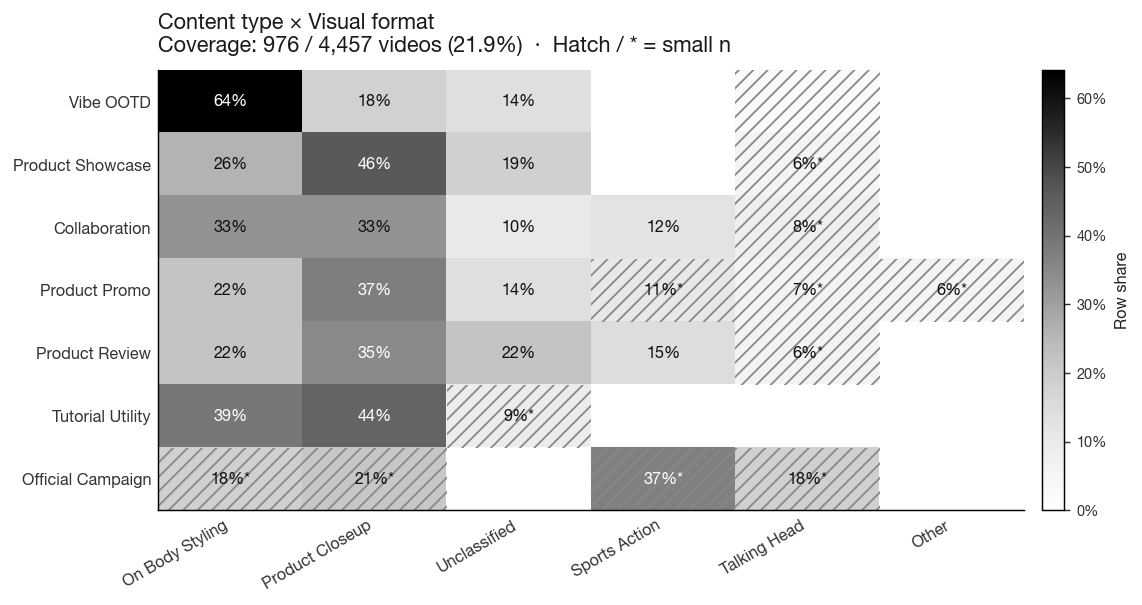

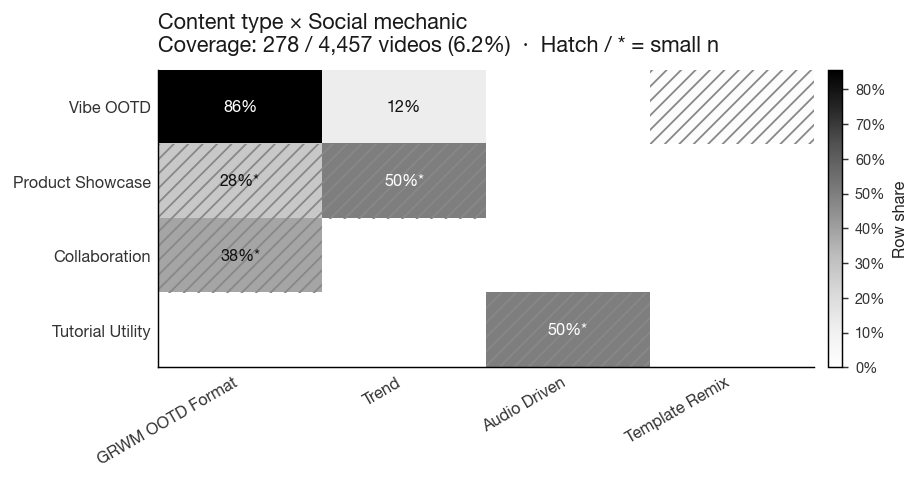

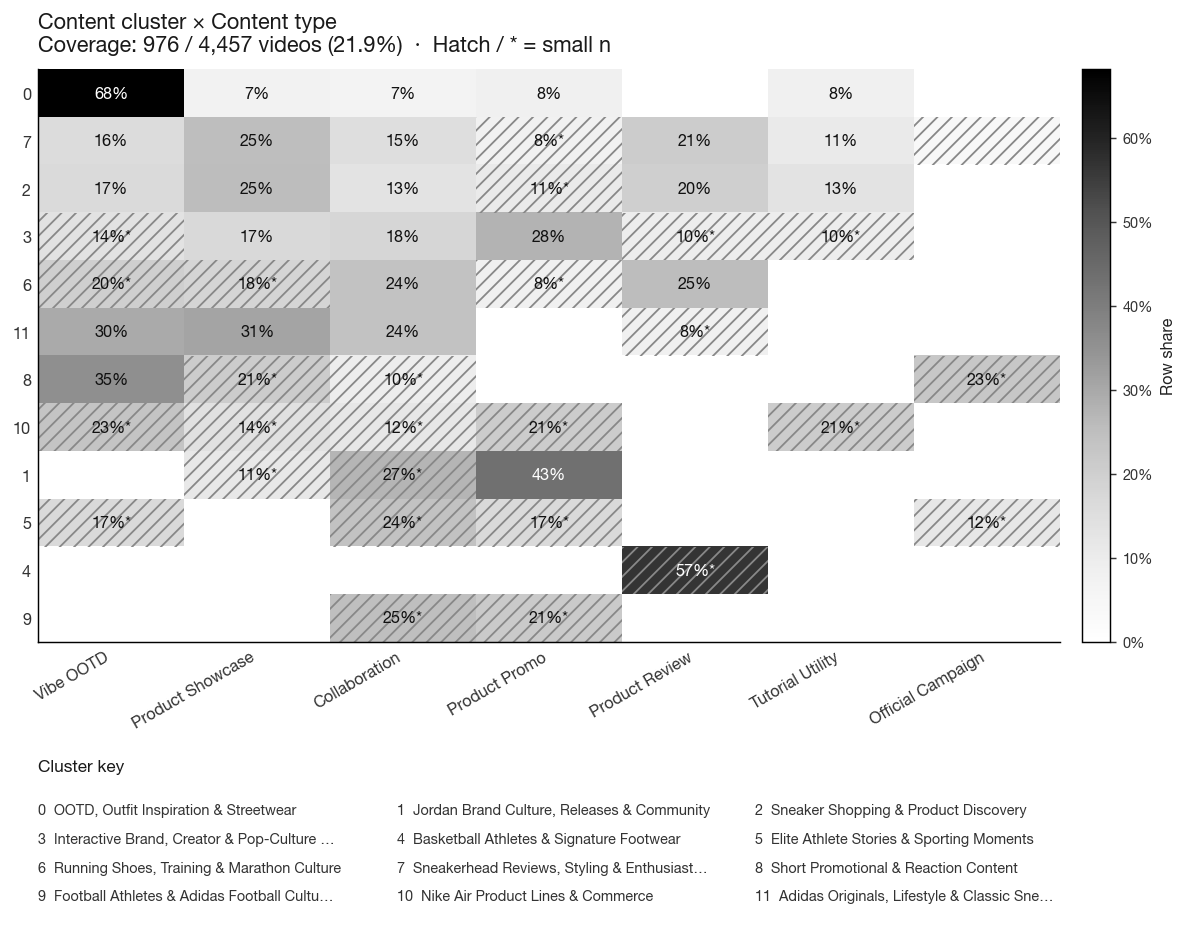

In [4]:
COMBOS = [
    ("content_type", "visual_format", "Content type × Visual format"),
    ("content_type", "social_mechanic", "Content type × Social mechanic"),
    ("content_cluster", "content_type", "Content cluster × Content type"),
]

for row, col, title in COMBOS:
    raw = crosstab_performance(df, row, col, min_count=5)
    print(coverage_annotation(raw))
    display(crosstab_heatmap(raw, row, col, title=title))


## Part 4 — What works

Category share vs median engagement (bubble size = n), then Nike vs Adidas WER with Mann–Whitney test.

Coverage: 976 / 4,457 videos (21.9%)
Coverage: 4,457 / 4,457 videos (100.0%)
Coverage: 585 / 4,457 videos (13.1%)
Coverage: 1,118 / 4,457 videos (25.1%)
Coverage: 4,457 / 4,457 videos (100.0%)
Mann–Whitney: {'median_nike': '0.005905', 'median_adidas': '0.007001', 'n_nike': 2314, 'n_adidas': 2139, 'U': '2.207e+06', 'p_value': '4.02e-10'}
Median views by brand:
brand
adidas    130,912
nike      100,199
Name: view_count, dtype: object


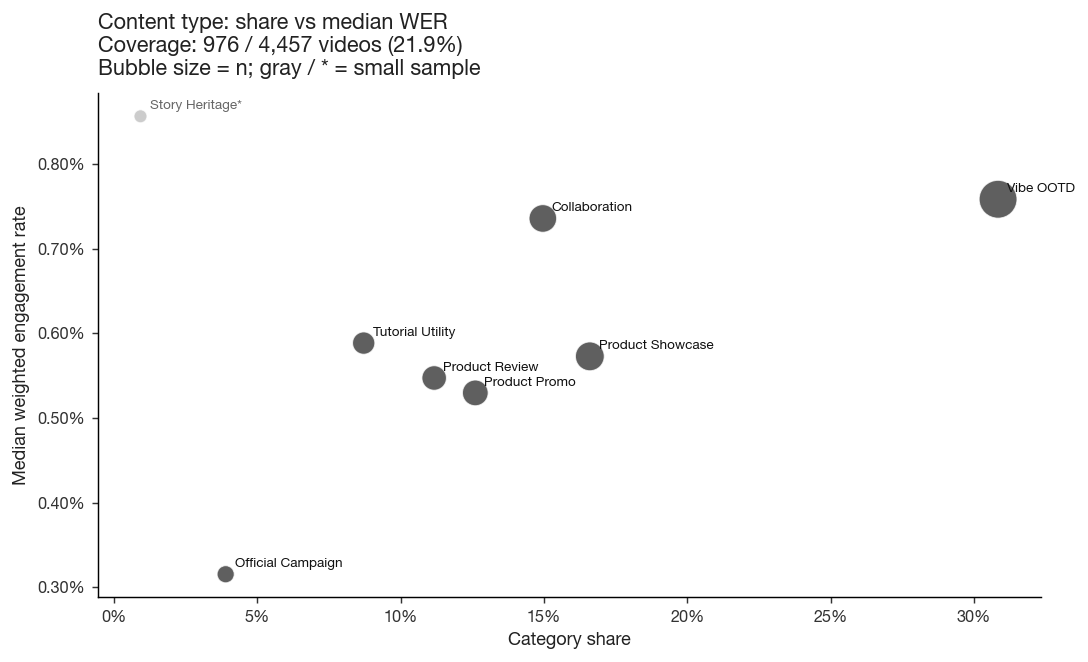

,Category,Share,Median WER,n,Median views
0,Vibe OOTD,30.8%,0.76%,301,"147,844"
1,Product Showcase,16.6%,0.57%,162,"54,532"
2,Collaboration,15.0%,0.74%,146,"82,682"
3,Product Promo,12.6%,0.53%,123,"104,527"
4,Product Review,11.2%,0.55%,109,"21,454"
5,Tutorial Utility,8.7%,0.59%,85,"601,824"
6,Official Campaign,3.9%,0.32%,38,"103,280"
7,Story Heritage,0.9%,0.86%,9,"42,834"


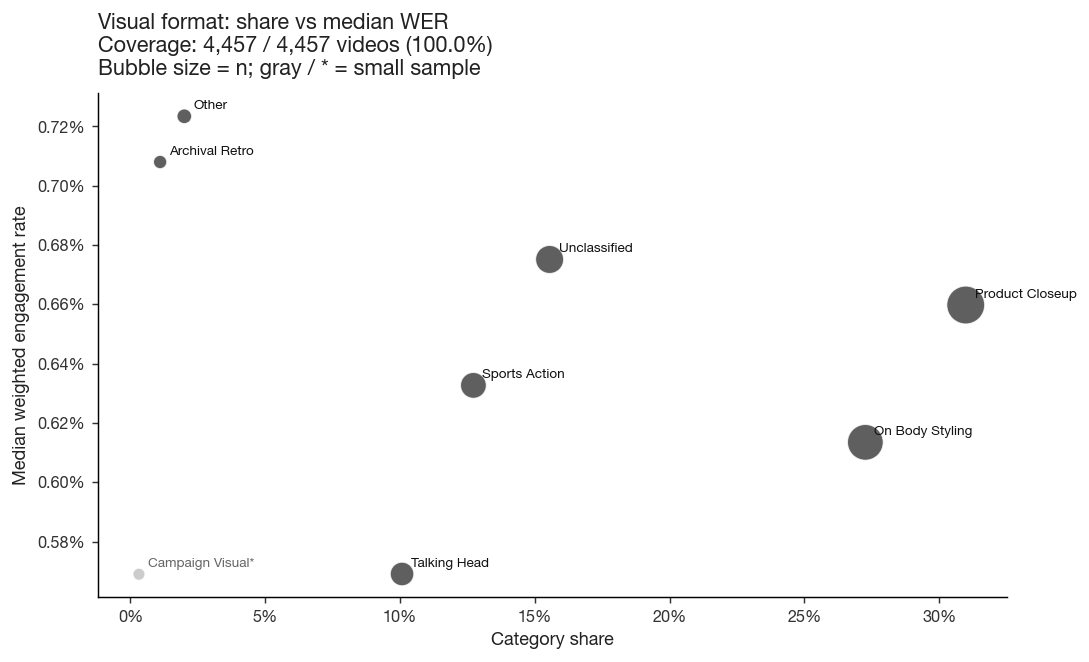

,Category,Share,Median WER,n,Median views
0,Product Closeup,31.0%,0.66%,"1,381","115,858"
1,On Body Styling,27.3%,0.61%,"1,215","130,174"
2,Unclassified,15.5%,0.68%,693,"98,928"
3,Sports Action,12.7%,0.63%,567,"97,212"
4,Talking Head,10.1%,0.57%,449,"116,644"
5,Other,2.0%,0.72%,89,"123,848"
6,Archival Retro,1.1%,0.71%,49,"37,686"
7,Campaign Visual,0.3%,0.57%,14,"566,300"


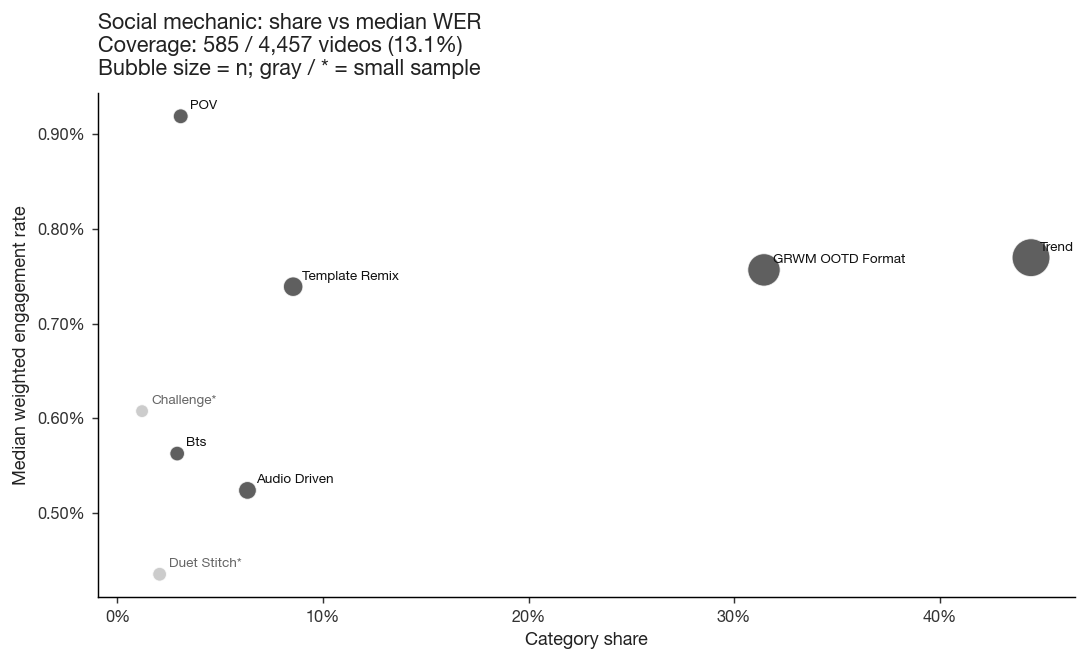

,Category,Share,Median WER,n,Median views
0,Trend,44.4%,0.77%,260,"255,273"
1,GRWM OOTD Format,31.5%,0.76%,184,"129,908"
2,Template Remix,8.5%,0.74%,50,"83,444"
3,Audio Driven,6.3%,0.52%,37,"488,277"
4,POV,3.1%,0.92%,18,"167,603"
5,Bts,2.9%,0.56%,17,"162,731"
6,Duet Stitch,2.1%,0.44%,12,"103,343"
7,Challenge,1.2%,0.61%,7,"603,297"


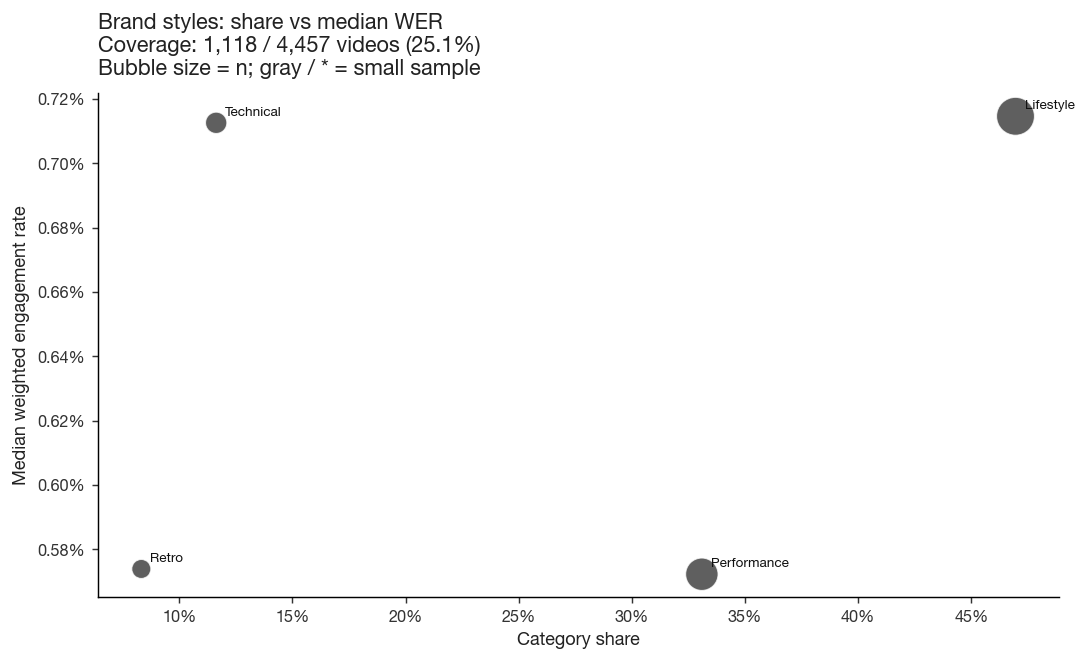

,Category,Share,Median WER,n,Median views
0,Lifestyle,47.0%,0.71%,525,"99,677"
1,Performance,33.1%,0.57%,370,"63,304"
2,Technical,11.6%,0.71%,130,"194,424"
3,Retro,8.3%,0.57%,93,"97,145"


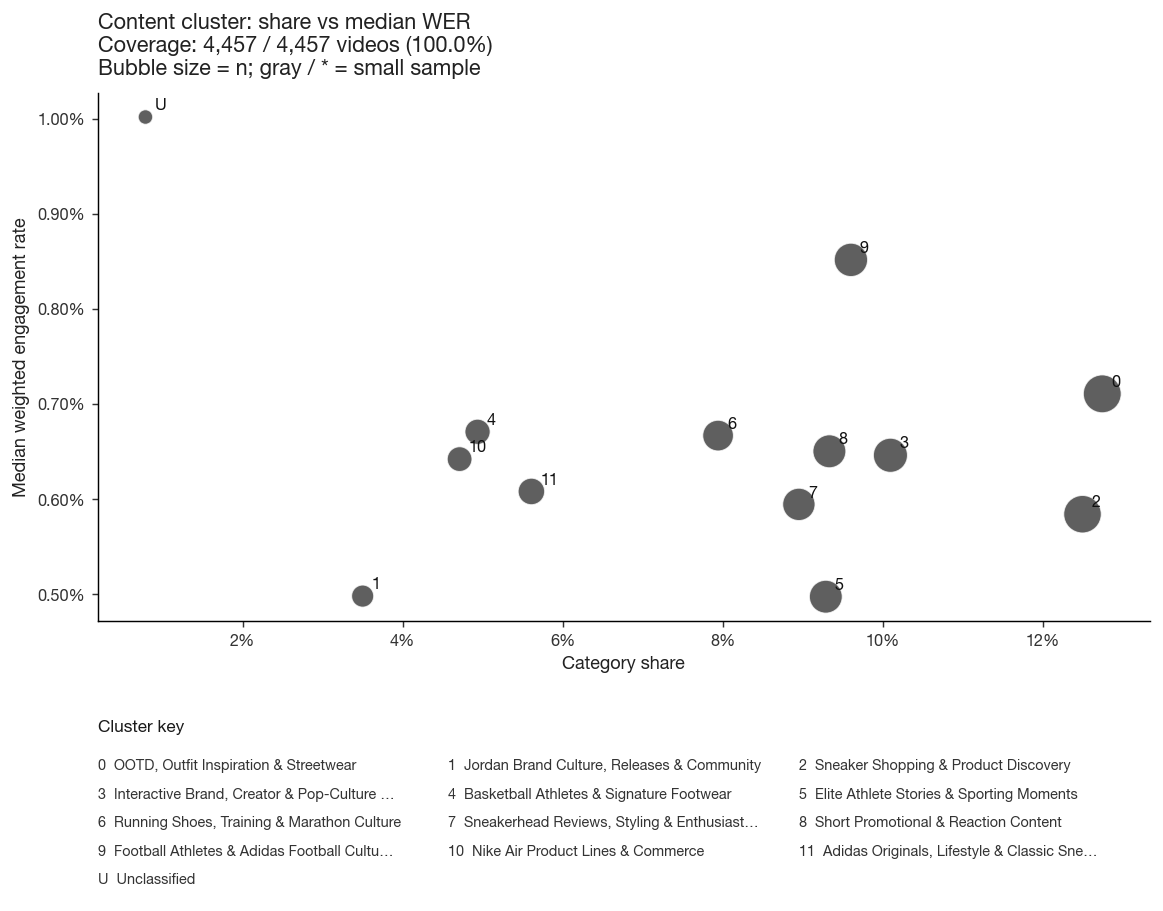

,Category,Share,Median WER,n,Median views
0,"0 — OOTD, Outfit Inspiration & Streetwear",12.7%,0.71%,568,"99,048"
1,2 — Sneaker Shopping & Product Discovery,12.5%,0.58%,557,"105,357"
2,"3 — Interactive Brand, Creator & Pop-Culture Content",10.1%,0.65%,450,"123,278"
3,9 — Football Athletes & Adidas Football Culture,9.6%,0.85%,428,"204,848"
4,8 — Short Promotional & Reaction Content,9.3%,0.65%,416,"166,134"
5,5 — Elite Athlete Stories & Sporting Moments,9.3%,0.50%,414,"92,986"
6,"7 — Sneakerhead Reviews, Styling & Enthusiast Culture",9.0%,0.59%,399,"143,154"
7,"6 — Running Shoes, Training & Marathon Culture",7.9%,0.67%,354,"26,054"
8,"11 — Adidas Originals, Lifestyle & Classic Sneaker Lines",5.6%,0.61%,250,"131,555"
9,4 — Basketball Athletes & Signature Footwear,4.9%,0.67%,220,"115,932"


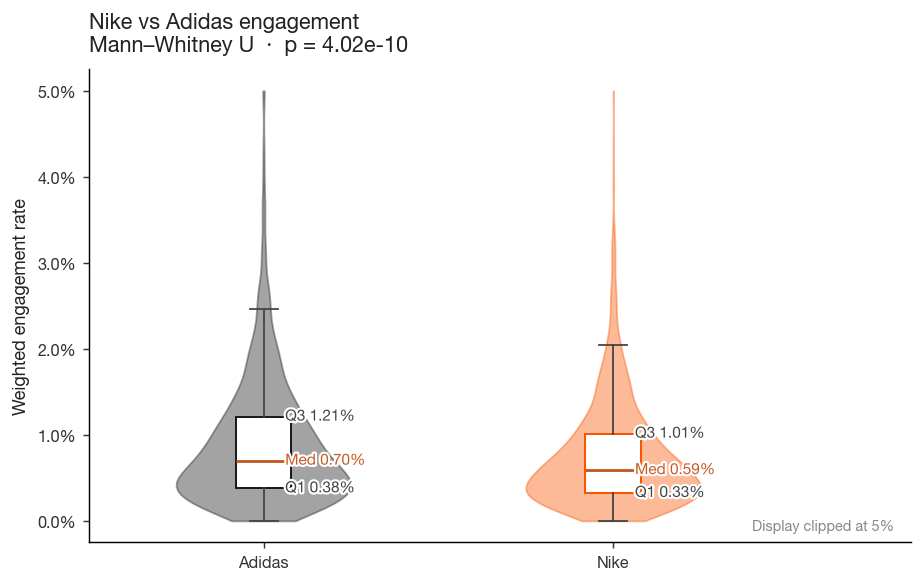

In [5]:
for col, title in LANDSCAPE_DIMS:
    raw = one_way_with_wer(df, col, min_count=5, include_views_median=True)
    print(coverage_annotation(raw))
    display(performance_bubble(raw, title=f"{title}: share vs median WER"))
    display(one_way_display_table(raw))

mw = mannwhitney_wer_by_brand(df)
print("Mann–Whitney:", {k: (f"{v:.4g}" if isinstance(v, float) else v) for k, v in mw.items()})
print("Median views by brand:")
print(df.groupby("brand")["view_count"].median().map(lambda x: f"{x:,.0f}"))
display(brand_wer_violin(df, mw))


## 4.2 Within-brand outperformance

**What content helps each brand outperform its own baseline?**

For each brand we use that brand’s **median** `weighted_engagement_rate` as the baseline, then score categories by:

`relative_index = category median WER / brand baseline`  
`relative_uplift = relative_index − 1`

This is **observational relative performance**, not causal lift. Small-n cells (n < 20) are hatched / marked `*` and are not treated as strategy winners.

### 4.2.1 Content type

Adidas vs Nike panels: relative uplift vs each brand’s own median WER.

Brand baseline median WER:
  adidas: 0.7001%
  nike: 0.5905%

Reliable only (n ≥ 20):

Category vs rest of brand (Mann–Whitney, BH-FDR):


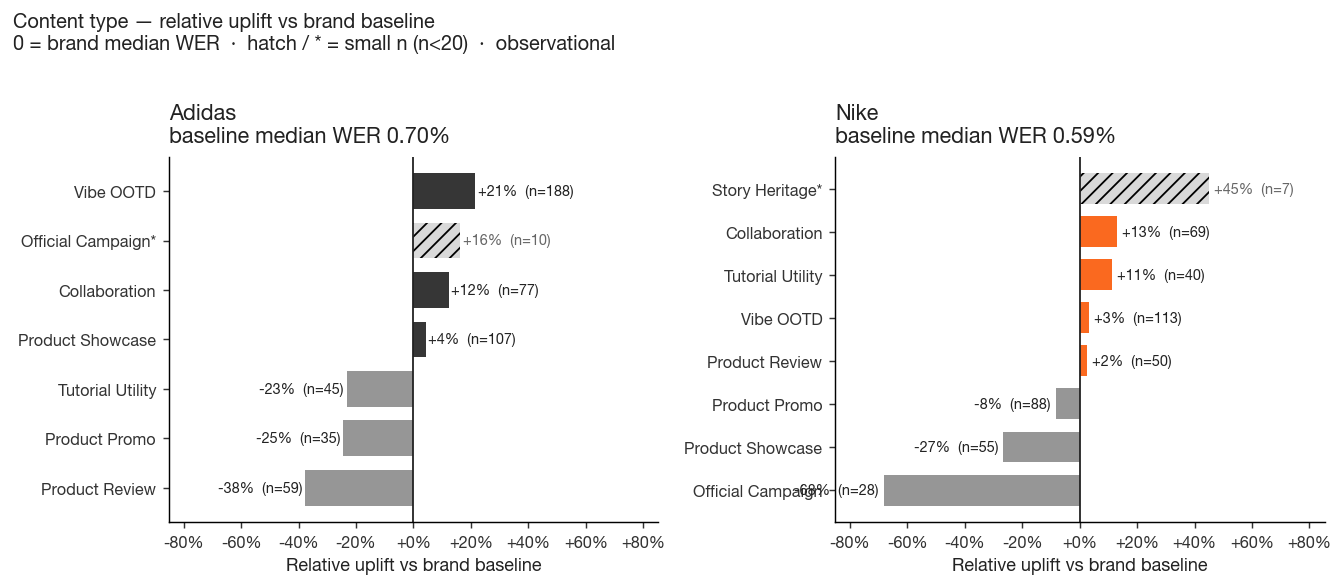

,Brand,Category,n,Median WER,Brand Baseline,Relative Index,Relative Uplift
0,Adidas,Vibe OOTD,188,0.85%,0.70%,1.21,+21%
1,Adidas,Official Campaign,10,0.81%,0.70%,1.16,+16%
2,Adidas,Collaboration,77,0.79%,0.70%,1.12,+12%
3,Adidas,Product Showcase,107,0.73%,0.70%,1.04,+4%
4,Adidas,Tutorial Utility,45,0.54%,0.70%,0.77,-23%
5,Adidas,Product Promo,35,0.53%,0.70%,0.75,-25%
6,Adidas,Product Review,59,0.44%,0.70%,0.62,-38%
7,Nike,Story Heritage,7,0.86%,0.59%,1.45,+45%
8,Nike,Collaboration,69,0.67%,0.59%,1.13,+13%
9,Nike,Tutorial Utility,40,0.66%,0.59%,1.11,+11%


,Brand,Category,n,Median WER,Brand Baseline,Relative Index,Relative Uplift
0,Adidas,Vibe OOTD,188,0.85%,0.70%,1.21,+21%
2,Adidas,Collaboration,77,0.79%,0.70%,1.12,+12%
3,Adidas,Product Showcase,107,0.73%,0.70%,1.04,+4%
4,Adidas,Tutorial Utility,45,0.54%,0.70%,0.77,-23%
5,Adidas,Product Promo,35,0.53%,0.70%,0.75,-25%
6,Adidas,Product Review,59,0.44%,0.70%,0.62,-38%
8,Nike,Collaboration,69,0.67%,0.59%,1.13,+13%
9,Nike,Tutorial Utility,40,0.66%,0.59%,1.11,+11%
10,Nike,Vibe OOTD,113,0.61%,0.59%,1.03,+3%
11,Nike,Product Review,50,0.60%,0.59%,1.02,+2%


,Brand,Category,n (cat),n (other),Med WER cat,Med WER other,p,p_adj (BH),Effect (r)
0,Adidas,Vibe OOTD,188,"1,951",0.85%,0.69%,0.011,0.076,-0.11
1,Adidas,Product Showcase,107,"2,032",0.73%,0.70%,0.227,0.470,+0.07
2,Nike,Collaboration,69,"2,245",0.67%,0.59%,0.268,0.470,-0.08
3,Nike,Vibe OOTD,113,"2,201",0.61%,0.59%,0.264,0.470,-0.06
4,Nike,Tutorial Utility,40,"2,274",0.66%,0.59%,0.563,0.789,-0.05
5,Nike,Product Review,50,"2,264",0.60%,0.59%,0.821,0.958,+0.02
6,Adidas,Collaboration,77,"2,062",0.79%,0.70%,0.964,0.964,-0.00


In [2]:
baselines = brand_baseline_wer(df)
print("Brand baseline median WER:")
for b, v in baselines.items():
    print(f"  {b}: {v:.4%}")

ct_rel = relative_performance_by_category(df, "content_type", min_count=5)
display(relative_uplift_diverging(ct_rel, title="Content type — relative uplift vs brand baseline"))
display(relative_display_table(ct_rel))

print("\nReliable only (n ≥ 20):")
display(relative_display_table(ct_rel, reliable_only=True))

# Mann–Whitney vs rest of brand for reliable outperformers (BH-FDR)
ct_candidates = ct_rel[(~ct_rel["small_n"]) & (ct_rel["relative_uplift"] > 0)].copy()
ct_tests = category_vs_rest_tests(df, "content_type", ct_candidates)
if len(ct_tests):
    print("\nCategory vs rest of brand (Mann–Whitney, BH-FDR):")
    display(tests_display_table(ct_tests))
else:
    print("\nNo reliable outperformers with enough sample for MW tests.")

### 4.2.2 Brand styles

Same within-brand baseline framing for positioning styles.


Reliable only (n ≥ 20):

Category vs rest of brand (Mann–Whitney, BH-FDR):


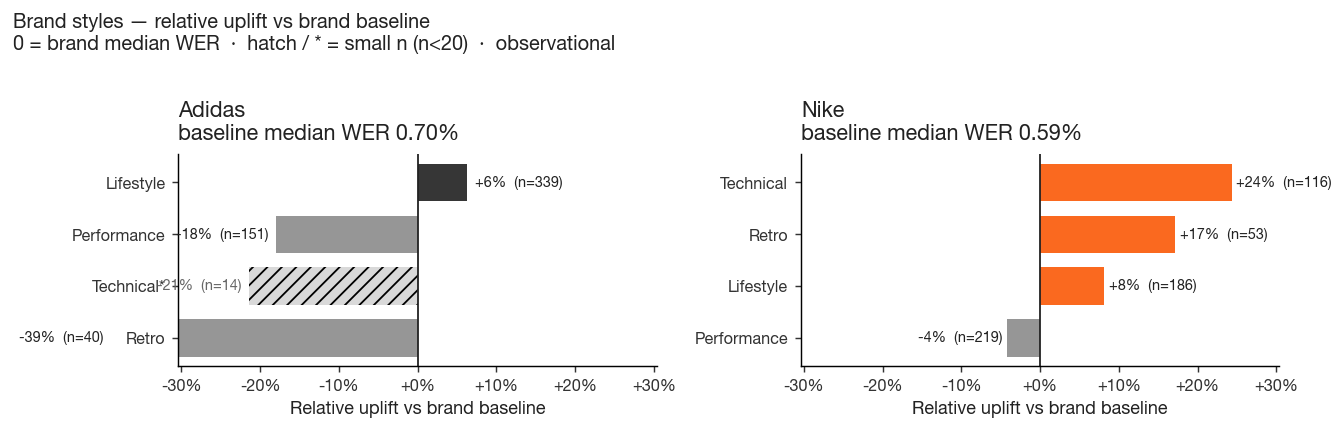

,Brand,Category,n,Median WER,Brand Baseline,Relative Index,Relative Uplift
0,Adidas,Lifestyle,339,0.74%,0.70%,1.06,+6%
1,Adidas,Performance,151,0.57%,0.70%,0.82,-18%
2,Adidas,Technical,14,0.55%,0.70%,0.79,-21%
3,Adidas,Retro,40,0.43%,0.70%,0.61,-39%
4,Nike,Technical,116,0.73%,0.59%,1.24,+24%
5,Nike,Retro,53,0.69%,0.59%,1.17,+17%
6,Nike,Lifestyle,186,0.64%,0.59%,1.08,+8%
7,Nike,Performance,219,0.57%,0.59%,0.96,-4%


,Brand,Category,n,Median WER,Brand Baseline,Relative Index,Relative Uplift
0,Adidas,Lifestyle,339,0.74%,0.70%,1.06,+6%
1,Adidas,Performance,151,0.57%,0.70%,0.82,-18%
3,Adidas,Retro,40,0.43%,0.70%,0.61,-39%
4,Nike,Technical,116,0.73%,0.59%,1.24,+24%
5,Nike,Retro,53,0.69%,0.59%,1.17,+17%
6,Nike,Lifestyle,186,0.64%,0.59%,1.08,+8%
7,Nike,Performance,219,0.57%,0.59%,0.96,-4%


,Brand,Category,n (cat),n (other),Med WER cat,Med WER other,p,p_adj (BH),Effect (r)
0,Nike,Technical,116,"2,198",0.73%,0.58%,0.002,0.007,-0.17
1,Adidas,Lifestyle,339,"1,800",0.74%,0.70%,0.255,0.343,-0.04
2,Nike,Retro,53,"2,261",0.69%,0.59%,0.343,0.343,-0.08
3,Nike,Lifestyle,186,"2,128",0.64%,0.59%,0.272,0.343,-0.05


In [3]:
bs_rel = relative_performance_by_category(df, "brand_styles", min_count=5)
display(relative_uplift_diverging(bs_rel, title="Brand styles — relative uplift vs brand baseline"))
display(relative_display_table(bs_rel))

print("\nReliable only (n ≥ 20):")
display(relative_display_table(bs_rel, reliable_only=True))

bs_candidates = bs_rel[(~bs_rel["small_n"]) & (bs_rel["relative_uplift"] > 0)].copy()
bs_tests = category_vs_rest_tests(df, "brand_styles", bs_candidates)
if len(bs_tests):
    print("\nCategory vs rest of brand (Mann–Whitney, BH-FDR):")
    display(tests_display_table(bs_tests))

### 4.2.3 Scalable winners

Share within brand vs relative uplift — separates niche spikes from strategically meaningful territories.

Combined view for **content_type** and **brand_styles**.

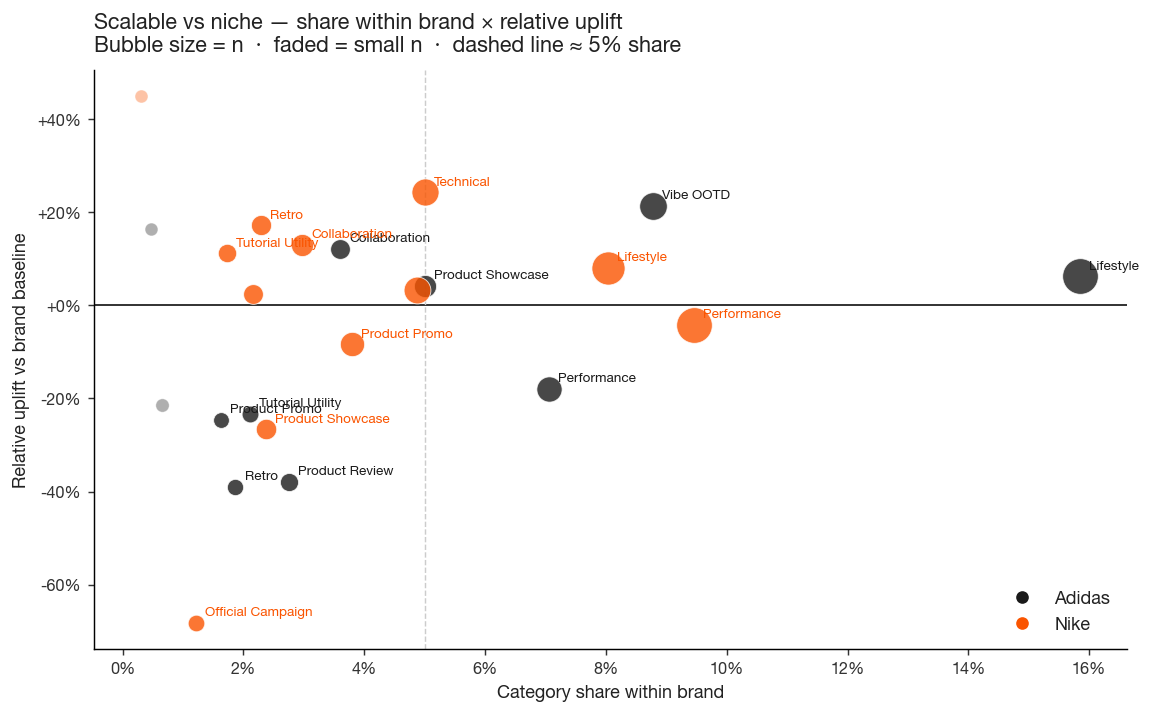

In [4]:
import pandas as pd

scalable = pd.concat(
    [
        ct_rel.assign(dimension="content_type"),
        bs_rel.assign(dimension="brand_styles"),
    ],
    ignore_index=True,
)
display(
    scalable_winners_scatter(
        scalable,
        title="Scalable vs niche — share within brand × relative uplift",
    )
)


## Key Findings

**Lifestyle / OOTD is the most prominent and relatively effective content direction overall.**  
Vibe / OOTD is the largest labeled content type, while Lifestyle is the dominant brand style. Both also show relatively strong median weighted engagement rates, suggesting that lifestyle-oriented content is not only widely used but also comparatively effective.

**Adidas and Nike follow clearly different content strategies.**  
Adidas is more heavily oriented toward lifestyle, styling, GRWM, and OOTD content, while Nike leans more toward technical, performance, sports-action, and promotional content.

**Adidas shows stronger overall engagement than Nike in this sample.**  
Adidas has a higher median weighted engagement rate than Nike, and the difference is statistically significant based on the Mann–Whitney U test.

**Platform-native, lifestyle-oriented, and collaborative formats tend to outperform more overtly promotional content.**  
Trend-led, GRWM / OOTD, and Collaboration content generally show stronger engagement than Product Promo and Official Campaign content, suggesting that greater promotional intensity does not necessarily translate into stronger audience response.

**The two brands outperform through different content territories.**  
Within-brand analysis shows that Adidas performs particularly well with Lifestyle and Vibe / OOTD content, whereas Nike’s stronger relative performance comes from Technical and Tutorial / Utility content. This suggests that each brand has a distinct set of content formats that performs best relative to its own engagement baseline.

**Collaboration is a consistent cross-brand opportunity.**  
Collaboration performs above each brand’s own baseline for both Adidas and Nike, making it one of the more reliable content territories across the two brands.

---

Overall, these findings suggest that content mix optimization should focus not only on what each brand publishes most often, but also on which content territories consistently outperform each brand’s own engagement baseline.
